# Amorphous Silicon Tersoff Lammps

### Anharmonic Lattice Dynamics (ALD) for $\ce{a-Si}$ with [Tersoff](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.37.6991)

#### Import Necessary Packges

In [1]:
from ase.io import read
from ase.visualize.plot import plot_atoms
from pylab import *
import warnings
warnings.filterwarnings("ignore")

#### Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequnecy or mean-free path

       input:
       observables: (ndarray) either phonon frequnecy or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       ouput:
       observeables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

#### Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

### Plot DOS, Participation Ratio (PPR) $\&$ Diffusivity

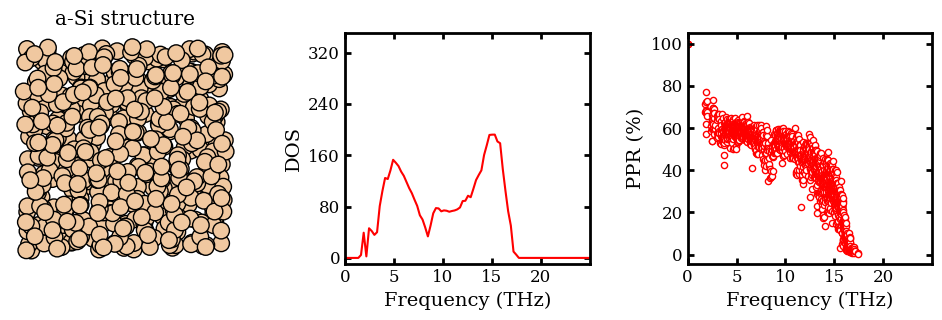

In [4]:
# Load in group velocity and frequency data
data_folder = './'
atoms = read(data_folder  + 'fc_aSi512/replicated_atoms.xyz')

frequency =  np.load(
    data_folder + 'ALD_aSi512/frequency.npy',
    allow_pickle=True)
ppr =  np.load(
    data_folder + 'ALD_aSi512/participation_ratio.npy',
    allow_pickle=True)
scattering_rate = np.load(
    data_folder + 'ALD_aSi512/300/quantum/tb_0.12091898428053205/_ps_and_gamma.npy',
    allow_pickle=True)[:, 1]
life_time = scattering_rate ** (-1)
dos = np.load(data_folder + 'plots/dos.npy', allow_pickle=True)
diffusivity = np.load(data_folder + 'diffusivity_quantum.npy', allow_pickle=True)

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3,1)
set_fig_properties([gca()])
plot_atoms(atoms, show_unit_cell=False, radii=0.8)
gca().axis('off')
gca().set_title('a-Si structure')

subplot(1,3, 2)
set_fig_properties([gca()])
plot(dos[0], dos[1], lw=1.5, c='r')
gca().set_xticks(np.arange(0, 25, 5))
gca().set_yticks(np.arange(0, 480, 80))
xlim([0, 25])
ylim([-10, 350])
xlabel('Frequency (THz)', fontsize=14)
ylabel('DOS', fontsize=14)

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency, 100.0 * ppr, facecolor='w', edgecolor='r', marker='o', s=20)
gca().set_xticks(np.arange(0, 25, 5))
xlabel('Frequency (THz)', fontsize=14)
ylabel('PPR (%)', fontsize=14)
xlim([0, 25])
subplots_adjust(wspace=0.4)
show()

#### Visualize per mode and cumulative $\kappa$

Bulk thermal conductivity: 1.244 W m^-1 K^-1

kappa matrix: 
[[1.0800165  0.26736617 0.20138611]
 [0.26736617 1.160652   0.2776317 ]
 [0.20138611 0.2776317  1.4918923 ]]




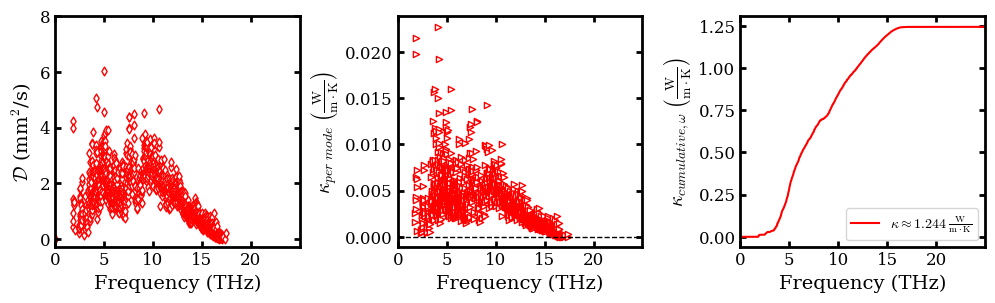

In [7]:
# Denote zeros to intake kappa tensor
kappa_tensor = np.load(data_folder + \
                       'ALD_aSi512/db_0.13706919455511365/qhgk/300/quantum/tb_0.12091898428053205/conductivity.npy', allow_pickle=True)


# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix = kappa_tensor.sum(axis=0)
print("Bulk thermal conductivity: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix)))
print("kappa matrix: ")
print(kappa_matrix)
print('\n')

# Compute kappa in per mode and cumulative representations
kappa_per_mode = kappa_tensor.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor)


# Plot observables in subplot
figure(figsize=(12, 3))

subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency, diffusivity, facecolor='w', edgecolor='r', marker='d', s=20)
gca().set_xticks(np.arange(0, 25, 5))
gca().set_yticks(np.arange(0, 10, 2))
xlim([0, 25])
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$\mathcal{D}$ (mm$^{2}$/s)', fontsize=14)
subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        kappa_per_mode, facecolor='w', edgecolor='r', s=20, marker='>')
gca().axhline(y = 0, color='k', ls='--', lw=1)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
gca().set_xticks(np.arange(0, 25, 5))
xlim([0, 25])

subplot(1,3, 3)
set_fig_properties([gca()])
plot(freq_sorted, kappa_cum_wrt_freq, 'r'
     , label=r"$\kappa \approx 1.244\;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$")
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=4, fontsize=10)
gca().set_xticks(np.arange(0, 25, 5))
xlim([0, 25])
subplots_adjust(wspace=0.4)
show()